# 🔍 Exploratory Data Analysis
**ROGII — Wellbore Geology Prediction**

> Understand the structure, distributions, missing values, and well-level statistics of the drilling and subsurface dataset.

---
**Author:** Md Ashraf | M.Sc (Tech) Applied Geophysics, IIT (ISM) Dhanbad

In [3]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yaml

from src import preprocessing, plotting

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
print('Libraries loaded ✅')

Libraries loaded ✅


In [4]:
# Load configuration
with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

DATA_DIR  = '../' + cfg['paths']['raw_dir']
TARGET    = cfg['data']['target_column']
WELL_COL  = cfg['data']['well_id_column']
DEPTH_COL = cfg['data']['depth_column']
print('Config loaded ✅')

Config loaded ✅


## 1. Load Data

In [9]:
from pathlib import Path

# Dataset paths
train_path = Path("/media/ashraf/Windows/Users/MD ASHRAF/Documents/wellbore-geology-prediction-Well-log/data/raw/train")
test_path  = Path("/media/ashraf/Windows/Users/MD ASHRAF/Documents/wellbore-geology-prediction-Well-log/data/raw/test")

print(f"Train folder: {train_path}")
print(f"Test folder : {test_path}")

# Get all horizontal well files
train_horizontal_files = sorted(train_path.glob("*_horizontal_well.csv"))
test_horizontal_files  = sorted(test_path.glob("*_horizontal_well.csv"))

print(f"\nTrain wells: {len(train_horizontal_files)}")
print(f"Test wells : {len(test_horizontal_files)}")

print("\nSample train wells:")
for f in train_horizontal_files[:5]:
    print(" -", f.name)

Train folder: /media/ashraf/Windows/Users/MD ASHRAF/Documents/wellbore-geology-prediction-Well-log/data/raw/train
Test folder : /media/ashraf/Windows/Users/MD ASHRAF/Documents/wellbore-geology-prediction-Well-log/data/raw/test

Train wells: 773
Test wells : 3

Sample train wells:
 - 000d7d20__horizontal_well.csv
 - 00bbac68__horizontal_well.csv
 - 00e12e8b__horizontal_well.csv
 - 015fe0d2__horizontal_well.csv
 - 01869cd4__horizontal_well.csv


## 2. Dataset Overview

In [10]:
print('=== TRAIN HEAD ===')
display(train.head())
print('\n=== DTYPES ===')
display(train.dtypes)

=== TRAIN HEAD ===


,well_id,md,tvd,inclination,azimuth,rop,wob,rpm,torque,flow_rate,ecd,gr,resistivity,neutron,density,sonic,formation
0,WELL_00,2000,1802.483571,84.723471,136.943066,22.403382,22.868353,116.487946,120.254028,423.023042,1.326526,87.468613,4.648675,0.226714,2.424196,70.867198,3
1,WELL_00,2002,1800.611109,84.144414,133.404548,11.623278,26.222653,108.480352,58.629167,398.960434,1.406717,63.283664,4.370499,0.345639,2.197328,101.194236,1
2,WELL_00,2004,1802.455170,83.728881,131.935343,11.419219,20.903265,119.917082,48.680317,411.680467,1.286744,115.122426,118.903595,0.309682,2.421864,98.817610,3
3,WELL_00,2006,1800.921759,84.397793,130.564434,9.134535,21.366160,135.856833,64.832638,347.108795,1.366204,55.006913,3.754961,0.280584,2.503100,99.312801,0
4,WELL_00,2008,1805.492201,85.347204,136.986854,13.416011,23.325297,137.471530,48.285251,376.909967,1.410609,123.562661,1.530883,0.281898,2.195558,100.694809,2



=== DTYPES ===


well_id         object
md               int64
tvd            float64
inclination    float64
azimuth        float64
rop            float64
wob            float64
rpm            float64
torque         float64
flow_rate      float64
ecd            float64
gr             float64
resistivity    float64
neutron        float64
density        float64
sonic          float64
formation        int64
dtype: object

In [11]:
print('=== DESCRIPTIVE STATISTICS ===')
display(train.describe().T.round(3))

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
md,2500.0,2499.000,288.732,2000.000,2249.500,2499.000,2748.500,2998.000
tvd,2500.0,1924.793,72.503,1791.600,1861.954,1925.480,1987.810,2059.166
inclination,2500.0,85.054,1.981,79.036,83.691,85.039,86.379,93.958
azimuth,2500.0,135.008,2.978,125.348,133.012,134.990,136.984,146.674
rop,2500.0,13.337,5.554,3.082,9.379,12.231,16.234,41.998
wob,2500.0,25.654,7.857,8.773,19.913,24.490,29.952,65.741
rpm,2500.0,119.518,14.868,66.477,109.075,119.432,129.515,166.013
torque,2500.0,62.453,33.431,10.673,39.088,55.615,77.322,277.398
flow_rate,2500.0,399.783,29.637,297.239,379.213,399.986,420.007,509.731
ecd,2500.0,1.348,0.051,1.183,1.313,1.347,1.383,1.513


## 3. Missing Value Analysis

In [12]:
missing = train.isnull().sum()
missing_pct = 100 * missing / len(train)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df.missing > 0].sort_values('pct', ascending=False)

if len(missing_df) > 0:
    fig = px.bar(
        missing_df.reset_index(),
        x='index', y='pct',
        title='Missing Value Percentage by Column',
        labels={'index': 'Column', 'pct': 'Missing (%)'},
        color='pct',
        color_continuous_scale='RdYlGn_r',
    )
    fig.show()
else:
    print('✅ No missing values found!')

✅ No missing values found!


## 4. Well-Level Statistics

In [13]:
well_stats = train.groupby(WELL_COL).agg(
    n_rows=('md', 'count'),
    md_min=('md', 'min'),
    md_max=('md', 'max'),
    md_range=('md', lambda x: x.max() - x.min()),
).reset_index()

display(well_stats)

fig = px.bar(
    well_stats, x=WELL_COL, y='n_rows',
    title='Number of Depth Rows per Well',
    color='md_range',
    color_continuous_scale='Viridis',
    labels={'n_rows': 'Row Count', 'md_range': 'MD Range (ft/m)'},
)
fig.show()

,well_id,n_rows,md_min,md_max,md_range
0,WELL_00,500,2000,2998,998
1,WELL_01,500,2000,2998,998
2,WELL_02,500,2000,2998,998
3,WELL_03,500,2000,2998,998
4,WELL_04,500,2000,2998,998


## 5. Target Distribution

In [14]:
if TARGET in train.columns:
    fig = px.histogram(
        train, x=TARGET,
        nbins=50,
        title=f'Target Distribution: {TARGET}',
        color_discrete_sequence=['#457B9D'],
    )
    fig.show()
    print(train[TARGET].describe())

count    2500.000000
mean        1.962400
std         1.401775
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: formation, dtype: float64


## 6. Feature Distributions

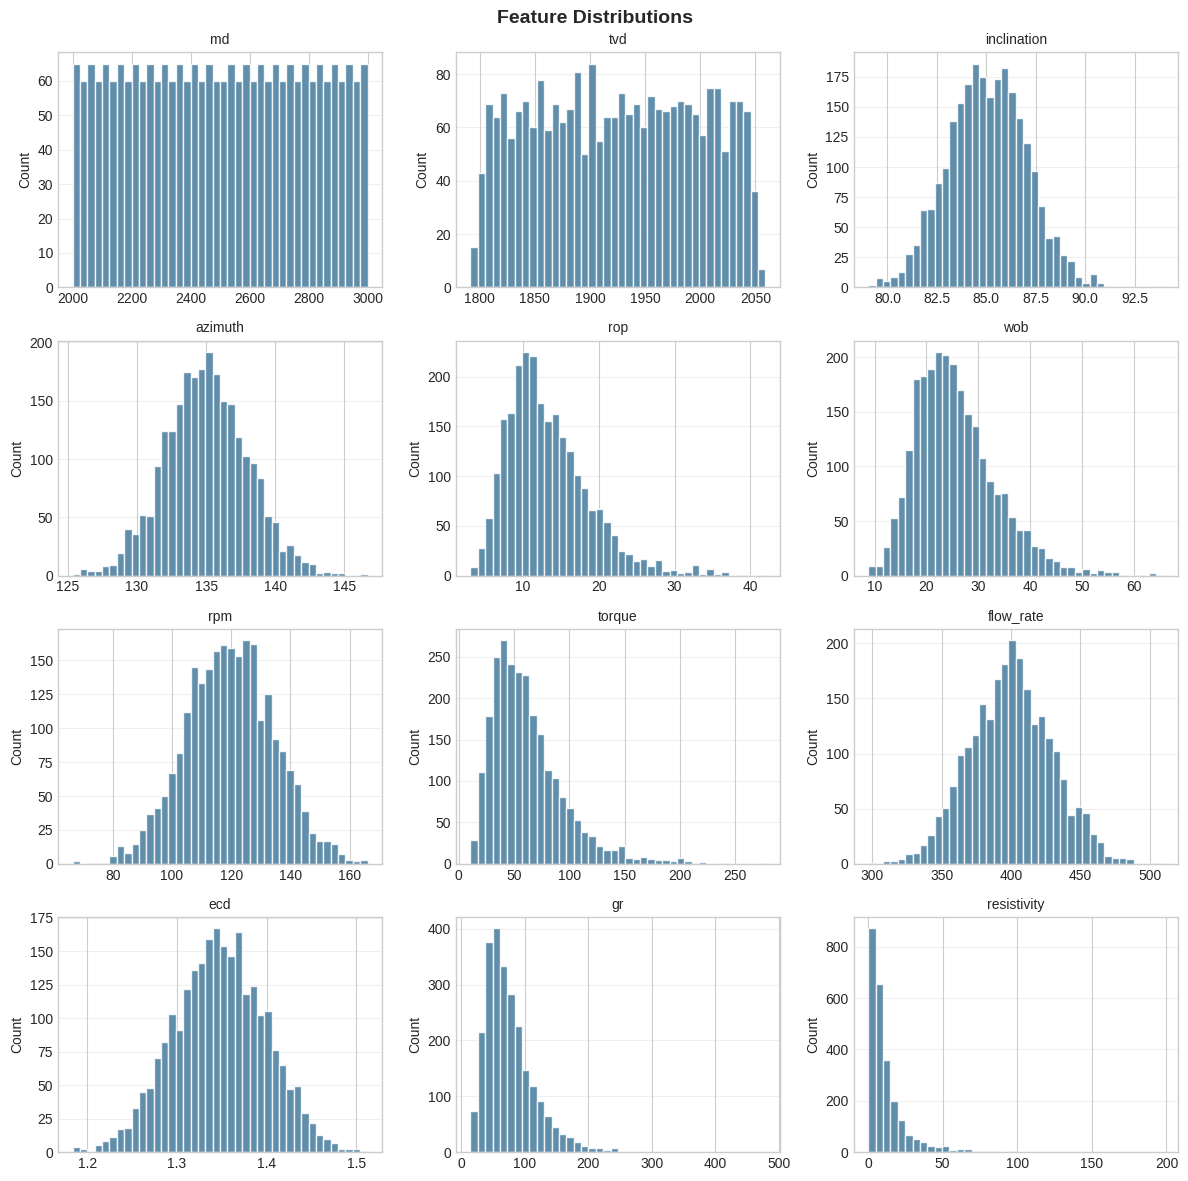

In [15]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in [TARGET, 'id']]

fig = plotting.plot_feature_distributions(train, feature_cols[:12])
plt.show()

## 7. Correlation Analysis

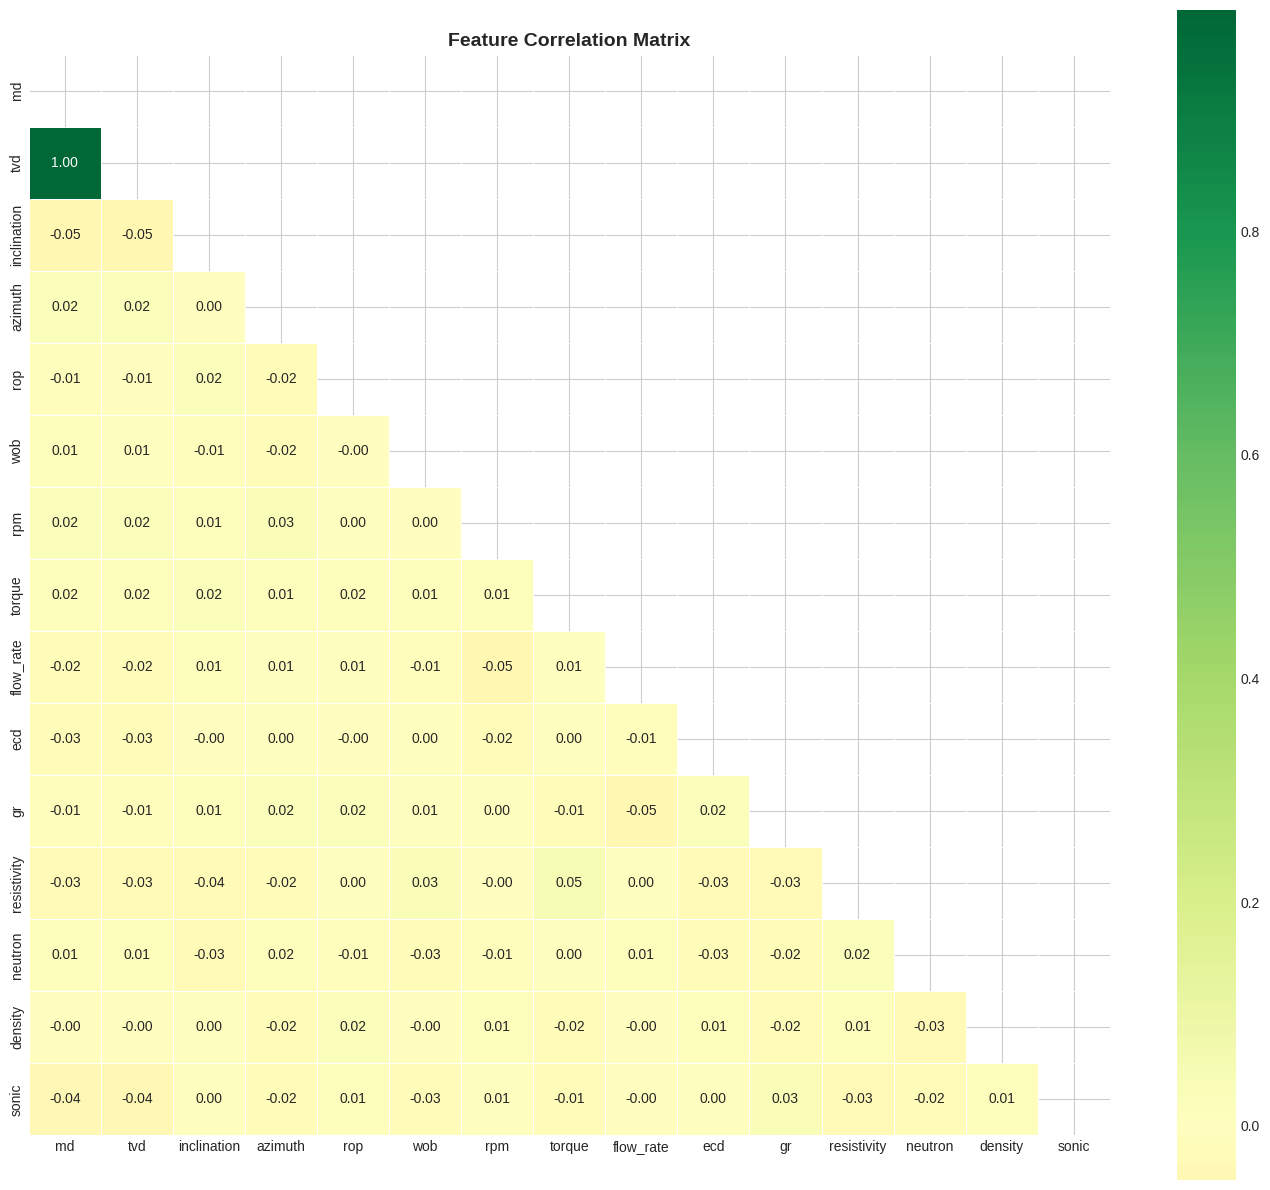

In [16]:
fig = plotting.plot_correlation_heatmap(train, feature_cols[:15])
plt.show()

## 8. Well Log Visualisation

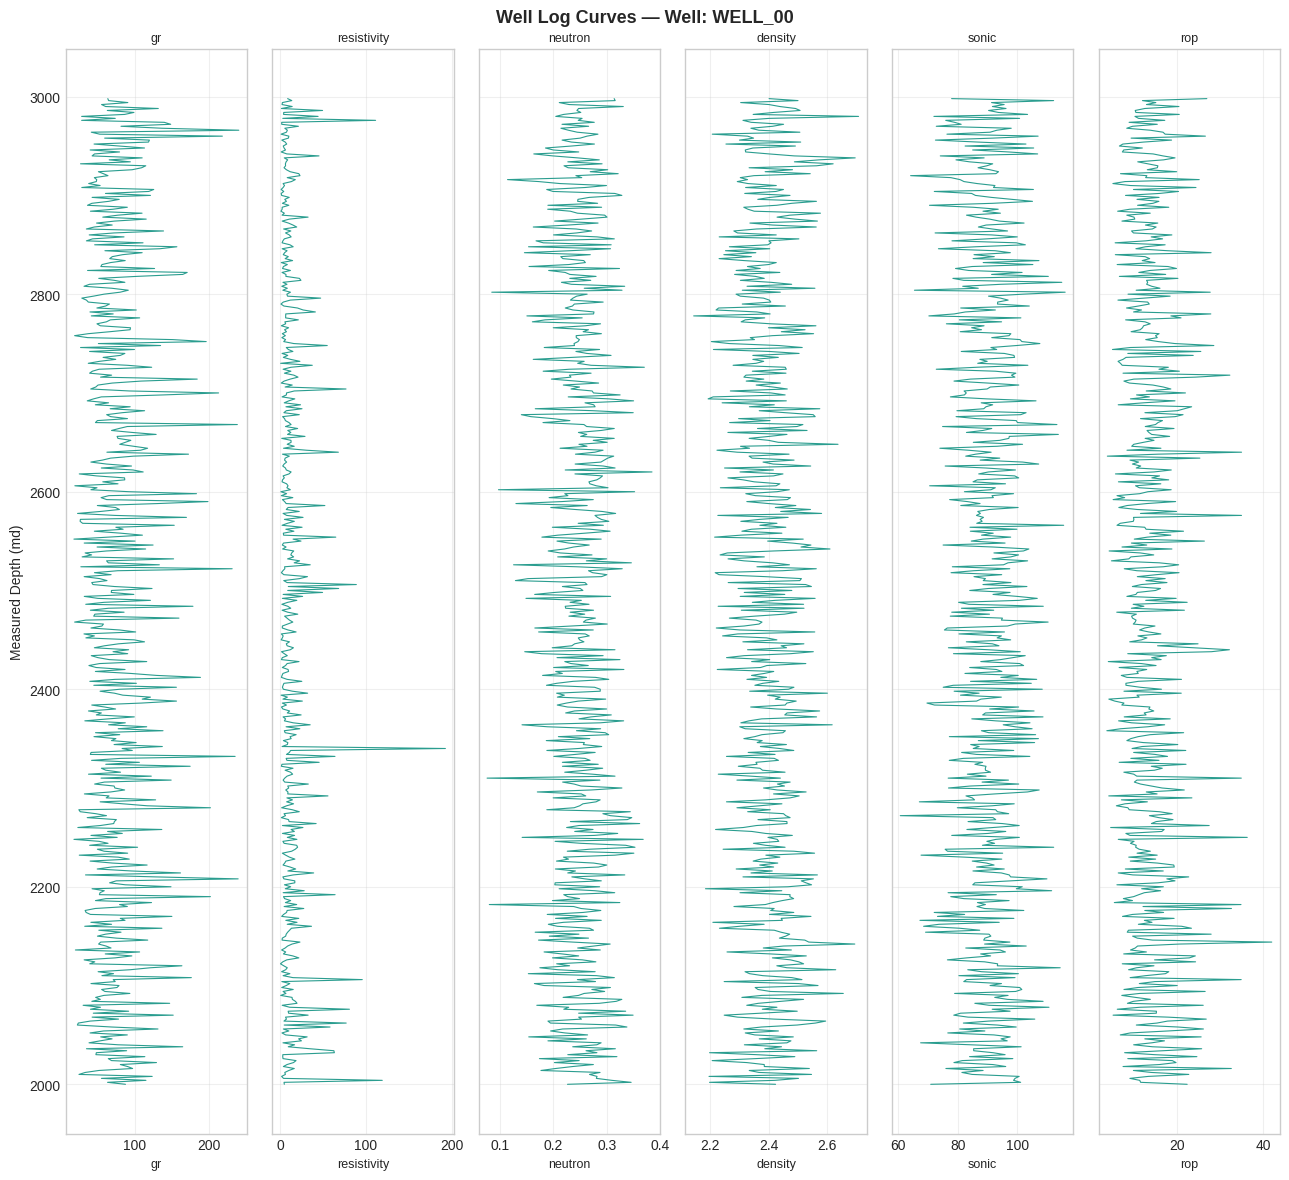

In [17]:
log_cols = ['gr', 'resistivity', 'neutron', 'density', 'sonic', 'rop']
available_log_cols = [c for c in log_cols if c in train.columns]

if available_log_cols and DEPTH_COL in train.columns:
    fig = plotting.plot_log_curves(
        train,
        depth_col=DEPTH_COL,
        log_cols=available_log_cols,
        well_col=WELL_COL,
    )
    plt.show()

## 9. Train vs Test Distribution Comparison

In [18]:
common_cols = [c for c in feature_cols[:6] if c in test.columns]

fig = make_subplots(rows=2, cols=3, subplot_titles=common_cols)

for i, col in enumerate(common_cols):
    row, col_idx = divmod(i, 3)
    fig.add_trace(
        go.Histogram(x=train[col], name='Train', opacity=0.6,
                     marker_color='#457B9D', showlegend=(i == 0)),
        row=row + 1, col=col_idx + 1,
    )
    fig.add_trace(
        go.Histogram(x=test[col], name='Test', opacity=0.6,
                     marker_color='#E63946', showlegend=(i == 0)),
        row=row + 1, col=col_idx + 1,
    )

fig.update_layout(
    title_text='Train vs Test Feature Distributions',
    barmode='overlay',
    height=500,
)
fig.show()

---
## ✅ Summary

**Key EDA findings:**
- Recorded observations per well, depth range, and data quality.
- Identified missing value patterns that require interpolation or forward-fill.
- Reviewed target distribution for skewness or outliers.
- Assessed train/test distribution shift for feature selection guidance.

**Next step → `02_feature_engineering.ipynb`**